## What are the most demanded skills for the top 3 most popular data roles?

### Methodology

1. Clean-up skill column
2. Calculate skill count based on Job_title_short
3. Calculate skill percentage
4. Plot final findings

In [5]:
# Importing Libraries 
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
 
from datasets import load_dataset
from matplotlib.ticker import FuncFormatter
from adjustText import adjust_text

In [6]:
# Loading Dataset 
raw = load_dataset('lukebarousse/data_jobs')
df = raw['train'].to_pandas().copy()

In [7]:
# Data Cleaning 
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

# Exploding the skill column
df_explode = df.explode('job_skills').copy()

In [ ]:
# Filtering for Jobs in the US
df_US = df_explode[df_explode['job_country']== 'United States']

In [20]:
# Grouping, converting series into frame and sorting the values 
df_skills = df_US.groupby(['job_skills','job_title_short']).size()
df_skills = df_skills.reset_index(name='skill_count')
df_skills = df_skills.sort_values(by='skill_count',ascending=False)
df_skills

,job_skills,job_title_short,skill_count
1209,python,Data Scientist,42379
1521,sql,Data Analyst,34452
1523,sql,Data Scientist,30034
455,excel,Data Analyst,27519
1243,r,Data Scientist,26022
...,...,...,...
1785,vue.js,Business Analyst,1
60,arch,Business Analyst,1
71,asana,Machine Learning Engineer,1
968,no-sql,Machine Learning Engineer,1


In [43]:
job_titles =df['job_title_short'].value_counts().head(3).index.tolist()
job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

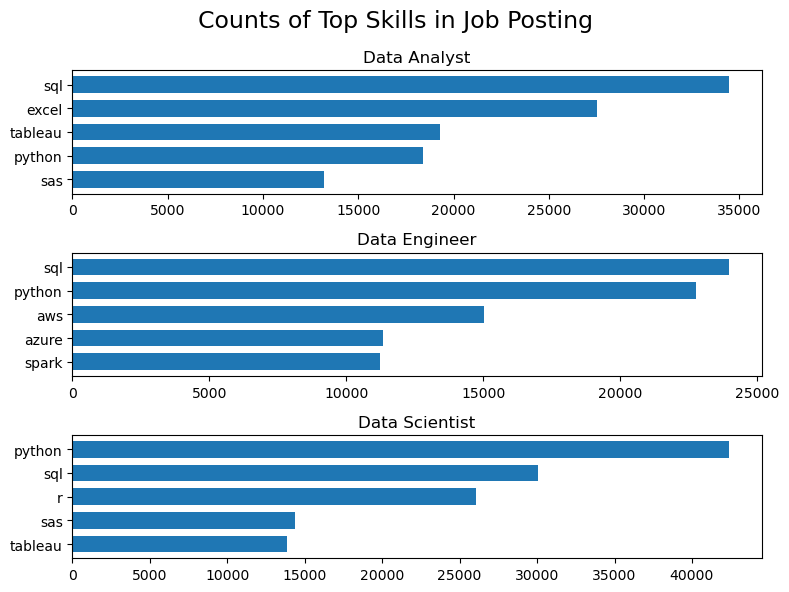

In [76]:
# ploting 
fig ,ax = plt.subplots(3,1,figsize=(8,6))
for i,title in enumerate(job_titles):
    df_plot = df_skills[df_skills['job_title_short']==title].head(5)
    df_plot.plot(kind='barh',x='job_skills',y='skill_count',ax=ax[i],title=title,width=0.7)
    ax[i].legend().remove()
    ax[i].set_ylabel('')
    ax[i].invert_yaxis()

fig.suptitle('Counts of Top Skills in Job Posting',fontsize=17)
fig.tight_layout()

In [82]:
df_jobs = df['job_title_short'].value_counts().reset_index(name='job_count')
df_jobs

,job_title_short,job_count
0,Data Analyst,196075
1,Data Engineer,186241
2,Data Scientist,172286
3,Business Analyst,49063
4,Software Engineer,44929
5,Senior Data Engineer,44563
6,Senior Data Scientist,36957
7,Senior Data Analyst,29216
8,Machine Learning Engineer,14080
9,Cloud Engineer,12331


In [87]:
df_skill_perc = df_skills.merge(df_jobs,how='left',on='job_title_short')
df_skill_perc['percentage'] = 100*df_skill_perc['skill_count']/df_skill_perc['job_count']
df_skill_perc

,job_skills,job_title_short,skill_count,job_count,percentage
0,python,Data Scientist,42379,172286,24.598052
1,sql,Data Analyst,34452,196075,17.570827
2,sql,Data Scientist,30034,172286,17.432641
3,excel,Data Analyst,27519,196075,14.034936
4,r,Data Scientist,26022,172286,15.103955
...,...,...,...,...,...
1865,vue.js,Business Analyst,1,49063,0.002038
1866,arch,Business Analyst,1,49063,0.002038
1867,asana,Machine Learning Engineer,1,14080,0.007102
1868,no-sql,Machine Learning Engineer,1,14080,0.007102


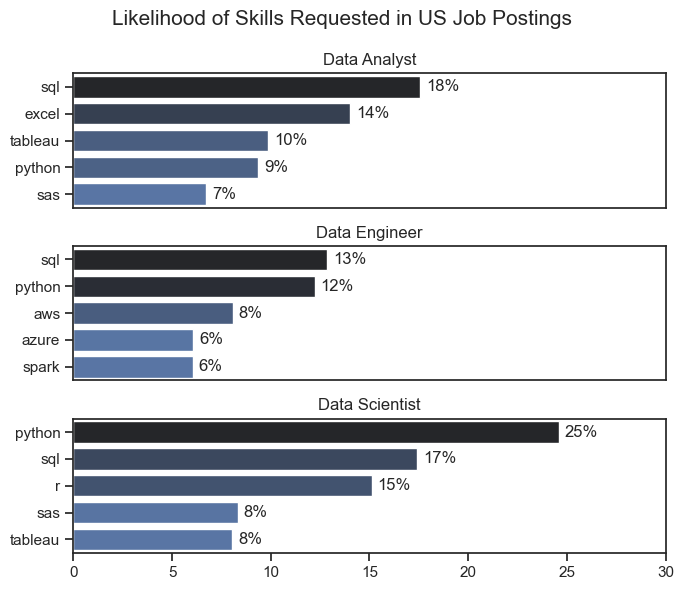

In [134]:
fig ,ax = plt.subplots(3,1,figsize=(7,6))

sns.set_theme(style='ticks')
for i,title in enumerate(job_titles):
    df_plot1 = df_skill_perc[df_skill_perc['job_title_short']==title].head(5)
    #df_plot1.plot(kind='barh',x='job_skills',y='percentage',ax=ax[i],title=title)
    
    sns.barplot(data=df_plot1,x='percentage',y='job_skills',ax=ax[i],hue='percentage',palette='dark:b_r')
    ax[i].set_title(title)
    ax[i].set_xlim(0,30)
    ax[i].legend().remove()
    #ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')

    for n,v in enumerate(df_plot1['percentage']):
        ax[i].text(v+0.3, n , f'{v:.0f}%',va='center')

    if i != len(job_titles)-1:
        ax[i].set_xticks([])

fig.suptitle('Likelihood of Skills Requested in US Job Postings', fontsize=15)
fig.tight_layout()
plt.show()